# 27 — Excitons and TDDFT: the bootstrap kernel

Everything in notebook 19 was a **static** response, solved orbital by orbital with the
Sternheimer equation. An *absorption spectrum* needs two things that construction does not
give: a frequency axis, and the susceptibility as a **matrix** over reciprocal lattice
vectors rather than as an operator. So this is the one place in pypresso where a sum over
states earns its keep.

$$\chi^0_{\mathbf{GG}'}(\omega)=\frac{1}{\Omega}\sum_{\mathbf k}\sum_{ij}
\frac{(f_i-f_j)\,\rho^{ij}_{\mathbf G}\rho^{ij*}_{\mathbf G'}}
{\epsilon_i-\epsilon_j+\omega+i\eta},
\qquad
\rho^{ij}_{\mathbf G}=\langle u_i|e^{-i\mathbf G\cdot\mathbf r}|u_j\rangle$$

and then the Dyson equation, with an exchange-correlation kernel that is not zero:

$$\epsilon^{-1}=1+X\left(1-X-\tilde f_{\rm xc}X\right)^{-1},\qquad X=v^{1/2}\chi^0v^{1/2}$$

The kernel here is the **bootstrap** of Sharma, Dewhurst, Sanna and Gross
([PRL **107**, 186401 (2011)](https://arxiv.org/abs/1107.0199)), which is Elk's
`fxctype = 210`. It is parameter-free and it is defined *by* the equation it feeds:

$$f^{\rm BS}_{\rm xc}=-\frac{\epsilon^{-1}(\mathbf q,0)\,v(\mathbf q)}{\epsilon_0(\mathbf q,0)-1},
\qquad \epsilon_0=1-v\chi^0$$

so the two are solved together until they stop moving. It diverges as $1/q^2$, and that is
what binds an electron–hole pair. **Quantum ESPRESSO has no counterpart**: `TDDFPT/` is a
Liouville–Lanczos solver with RPA and ALDA, with no bootstrap kernel and no Dyson equation
in $\mathbf G$ space.

**Headline number.** There is no other code's spectrum to compare against — Elk is
all-electron LAPW where this is a pseudopotential plane wave — so the validation is an
*identity*: the same $\epsilon_M(0)$ reached by this sum over states plus a Dyson
inversion, and by the projected conjugate-gradient solve of notebook 19, which shares no
machinery with it and never sees an empty state. They agree to **1.3e-2 on a constant of
22**, and what is left is the band truncation, which is reported rather than tuned away.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from pypresso import Calculator
from pypresso.scf import Calculation, run_scf
from pypresso.units import RY_TO_EV

DATA = Path("..") / "tests" / "data"

# The unshifted, closed 4x4x4 grid with `nosym`. chi_0(G, G') is a matrix in *two*
# G indices, and symmetrising it would rotate both at once -- which nothing here
# does -- so this phase needs the whole grid, and an unshifted one is what makes
# running it without symmetry sound in the first place.
silicon = Calculator.from_file(DATA / "qe" / "si-epsilon-unshifted-nosym.in",
                               pseudo_dir=DATA / "pseudo", announce=False,
                               conv_thr=1e-12)
system, pseudos = silicon.system, silicon.pseudos

scf = silicon.get_scf(max_iterations=80)
print(f"{system.kpoints.nk} k-points, E = {float(scf.total_energy):.8f} Ry")

64 k-points, E = -15.83064709 Ry


## The spectrum, three kernels

`run_absorption` is the one-call entry point and does everything: a fixed-density run with
empty states, `chi_0`, and the Dyson equation. But `chi_0` is the whole cost and the kernel
is nearly free, so comparing kernels means building it **once** and solving the Dyson
equation three times — which is also the clearest way to see where the expense is.

In [2]:
from pypresso.workflows.nscf import fixed_density_states
from pypresso.tddft import independent_response, solve_dyson, alda_matrix
import jax.numpy as jnp, time

# One fixed-density run with empty states. `nbnd` is the convergence parameter of
# this whole phase and nothing can refuse it being too small -- hence the
# residual measured further down.
calc, _, evals, wfs = fixed_density_states(system, pseudos, scf.density,
                                           nbnd=60, conv_thr=1e-10)
potential = calc.potential(jnp.asarray(scf.density))

omega = np.arange(0.0, 0.60, 0.004)                  # Ry
t = time.time()
chi = independent_response(
    calc, wfs, evals, potential.v_scf,
    np.concatenate([[0.0], omega]),   # one extra point at omega = 0: the kernel's
    ecut_response=8.0,                # Elk's gmaxrf -- the G-set chi_0 spans
    broadening=0.012,                 # Elk's swidth, and the width of every peak
)
print(f"chi_0: {chi.nm} x {chi.nm} at {len(omega) + 1} frequencies, "
      f"{chi.npairs} pairs per k-point, {time.time() - t:.0f} s")

context = {"alda_matrix": alda_matrix(calc, jnp.asarray(scf.density), chi.sphere)}
solutions, spectra = {}, {}
for kernel in ("rpa", "alda", "bootstrap"):
    t = time.time()
    solutions[kernel] = solve_dyson(chi, kernel, context)
    epsilon = np.asarray(solutions[kernel].epsilon)[1:]
    spectra[kernel] = np.imag(np.trace(epsilon, axis1=1, axis2=2)) / 3.0
    print(f"  {kernel:10s} {time.time() - t:5.2f} s   "
          f"alpha = {solutions[kernel].alpha:+.4f}   "
          f"{solutions[kernel].iterations} pass(es)")

chi_0: 115 x 115 at 151 frequencies, 224 pairs per k-point, 4 s


  rpa         0.56 s   alpha = -0.0000   1 pass(es)


  alda        0.45 s   alpha = -0.0000   1 pass(es)


  bootstrap   2.80 s   alpha = +0.0232   9 pass(es)


## The figure

An attractive kernel moves oscillator strength **downhill**. Silicon has no *bound*
exciton — there is no peak below the gap to find — so what shows here is the
redistribution, which is what the bootstrap paper's silicon panel shows too (an enhanced
$E_1$ shoulder at the expense of $E_2$).

rpa        weight below RPA's peak: 0.5706   first moment: 3.6477 eV
alda       weight below RPA's peak: 0.6138   first moment: 3.5916 eV
bootstrap  weight below RPA's peak: 0.6085   first moment: 3.5873 eV


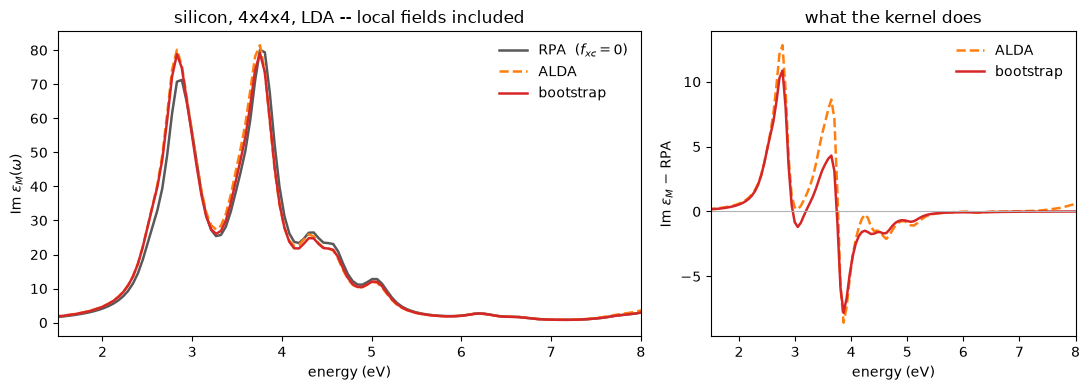

In [3]:
fig, (ax, axr) = plt.subplots(1, 2, figsize=(11, 4), width_ratios=[1.6, 1])

ev = omega * RY_TO_EV
style = {"rpa": ("0.35", "-", r"RPA  ($f_{xc}=0$)"),
         "alda": ("tab:orange", "--", "ALDA"),
         "bootstrap": ("tab:red", "-", "bootstrap")}
for name, (colour, dash, label) in style.items():
    ax.plot(ev, spectra[name], dash, color=colour, lw=1.8, label=label)
ax.set_xlabel("energy (eV)"); ax.set_ylabel(r"Im $\epsilon_M(\omega)$")
ax.set_title("silicon, 4x4x4, LDA -- local fields included")
ax.legend(frameon=False); ax.set_xlim(1.5, 8)

# The same thing as a difference, which is where the effect actually lives.
for name in ("alda", "bootstrap"):
    axr.plot(ev, spectra[name] - spectra["rpa"], style[name][1],
             color=style[name][0], lw=1.8, label=style[name][2])
axr.axhline(0.0, color="0.7", lw=0.8)
axr.set_xlabel("energy (eV)"); axr.set_ylabel(r"Im $\epsilon_M$ $-$ RPA")
axr.set_title("what the kernel does"); axr.legend(frameon=False); axr.set_xlim(1.5, 8)
fig.tight_layout()

peak = int(np.argmax(spectra["rpa"]))          # a *common* cut for all three
for name in style:
    a = spectra[name]
    print(f"{name:10s} weight below RPA's peak: {a[:peak].sum()/a.sum():.4f}   "
          f"first moment: {(omega*a).sum()/a.sum()*RY_TO_EV:.4f} eV")

The cut has to be **common**. Measuring each spectrum's weight below *its own* maximum
moves the window with the spectrum and reverses the answer — 0.594 for the bootstrap
against 0.606 for RPA on its own peak, and 0.643 against 0.606 on a shared one.

ALDA moves weight too, and it would be wrong to say otherwise. What it cannot do is
*bind*, and the reason is structural rather than a matter of size — see below.

## The identity that certifies it

Two routes to $\epsilon_M(0)$ that share the ground state and nothing else. The
sum over states builds a matrix from occupied–empty pairs and inverts a Dyson equation;
the Sternheimer route never forms a matrix, never sees an empty state, and solves
$(\hat H-\epsilon_n\hat S)|\Delta\psi\rangle=-\hat P_c\,\mathbf r|\psi\rangle$ by
conjugate gradient.

**The pairing is the content of the check.** `dielectric_tensor`'s screening kernel is one
`jvp` of `v_of_rho`, so it is Hartree *plus* $f_{xc}$: it is the **ALDA** answer, not the
RPA one. Comparing an RPA sum over states against it is not an identity at all, and the
residue — six percent here — looks exactly like band truncation. Hence the
`screening` switch.

In [4]:
from pypresso.response.efield import dielectric_tensor

nocc = int(round(calc.nelec / 2))

# chi_0 again at omega = 0 with **no** broadening, so it is comparable with a
# Sternheimer solve, which has none either. One frequency, so it is cheap.
static = independent_response(calc, wfs, evals, potential.v_scf, np.array([0.0]),
                              ecut_response=8.0, broadening=0.0)
static_context = {"alda_matrix": alda_matrix(calc, jnp.asarray(scf.density),
                                             static.sphere)}

print(f"{'kernel':10s} {'sum over states':>16s} {'Sternheimer':>13s} {'diff':>9s}")
sternheimer = {}
for kernel, screening in (("rpa", "hartree"), ("alda", "full")):
    reference = dielectric_tensor(calc, wfs[:, :, :nocc], evals[:, :, :nocc],
                                  jnp.asarray(scf.density), screening=screening,
                                  born_charges=False)
    sternheimer[kernel] = float(np.diag(np.asarray(reference.epsilon)).mean())
    solution = solve_dyson(static, kernel, static_context)
    here = float(np.real(np.diag(np.asarray(solution.epsilon)[0])).mean())
    print(f"{kernel:10s} {here:16.4f} {sternheimer[kernel]:13.4f} "
          f"{here - sternheimer[kernel]:9.1e}")

mismatch = abs(sternheimer["alda"] - sternheimer["rpa"])
print(f"\nMismatch the pairing and the residue is {mismatch:.3f} on ~22 -- "
      f"{100 * mismatch / sternheimer['rpa']:.0f}%, and it is f_xc,")
print("not a convergence error. That is what the `screening` switch is for.")

kernel      sum over states   Sternheimer      diff


rpa                 22.3322       22.3451  -1.3e-02


alda                23.6214       23.6088   1.3e-02

Mismatch the pairing and the residue is 1.264 on ~22 -- 6%, and it is f_xc,
not a convergence error. That is what the `screening` switch is for.


## Why ALDA cannot bind, in one line of output

The symmetrised kernel is $\tilde f_{xc}=v^{-1/2}f_{xc}v^{-1/2}$. ALDA's $f_{xc}$ is
**finite** at $\mathbf q=0$ while $v$ **diverges**, so its head and wings vanish
identically — the optical limit never feels it. The bootstrap's does not vanish, because
its numerator carries $v(\mathbf q)$ itself. That is the entire difference between the two,
and it is a statement about shape rather than about magnitude.

In [5]:
for name in ("alda", "bootstrap"):
    f = np.asarray(solutions[name].fxc)[0]
    print(f"{name:10s} |head| = {np.abs(f[:3, :3]).max():.3e}   "
          f"|wings| = {np.abs(f[:3, 3:]).max():.3e}   "
          f"|body| = {np.abs(f[3:, 3:]).max():.3e}")

print("\nAnd the one-call entry point, which does all of the above at once:")
print("    from pypresso.workflows import run_absorption")
print("    run_absorption(system, pseudos, scf.density, omega,")
print("                   kernel='bootstrap', nbnd=60, ecut_response=8.0,")
print("                   broadening=0.012, scissor=0.05)")

alda       |head| = 0.000e+00   |wings| = 0.000e+00   |body| = 3.173e+00
bootstrap  |head| = 1.847e-03   |wings| = 5.025e-04   |body| = 4.204e-02

And the one-call entry point, which does all of the above at once:
    from pypresso.workflows import run_absorption
    run_absorption(system, pseudos, scf.density, omega,
                   kernel='bootstrap', nbnd=60, ecut_response=8.0,
                   broadening=0.012, scissor=0.05)


## Two traps, both of which leave a perfectly plausible spectrum

**$\epsilon_M$ is the inverse of the $3\times3$ head of $\epsilon^{-1}$, not the head of
the inverse of the whole matrix.** Elk writes both from one array thirty lines apart
(`EPSILON_TDDFT_ij.OUT` against `EPSM_TDDFT_ij.OUT`). Taking the wrong one is not an
approximation: in RPA it is *identically* the no-local-field result — smooth, positive,
right peaks, and 9% too large.

**Band truncation has no refusal.** An undersized sum gives a spectrum that looks fine, so
`static_residual` measures it against the band-complete Sternheimer route. It is
kernel-matched *and* scissor-matched, because differencing two routes measures every way
they differ: a 0.05 Ry scissors shift turns a `+0.013` residual into `-3.46` if the other
side does not have one.

---

**Where the detail is.** `PLAN.md` P37 has the derivation, the four findings and the
per-case table; `tests/regression/test_tddft.py` has the identities and
`tests/unit/test_tddft_machinery.py` the refusals. The reference is Elk's `tddftlr.f90`,
`genvchi0.f90` and `genvfxc.f90`.

**Refused by name:** finite $\mathbf q$, ultrasoft and PAW, metals, spin in any form, a
symmetry-reduced k-set, ALDA with a gradient-corrected functional, and a bootstrap fixed
point that has not converged.